_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names: <span style='background: yellow'>Andre Pothoff, Lucía Grande, Niclas Collmer </span>

LLM Disclaimer: <span style='background: yellow'>*Did you use an LLM to solve this exercise? If yes, which?  Where and how did you use it? [Copilot, ChatGPT, Claude-Code etc.]* </span>

# Coding Lab 1

## Introduction

In this coding lab you get to implement a pipeline for spike detection and feature extraction, as presented in the lecture:
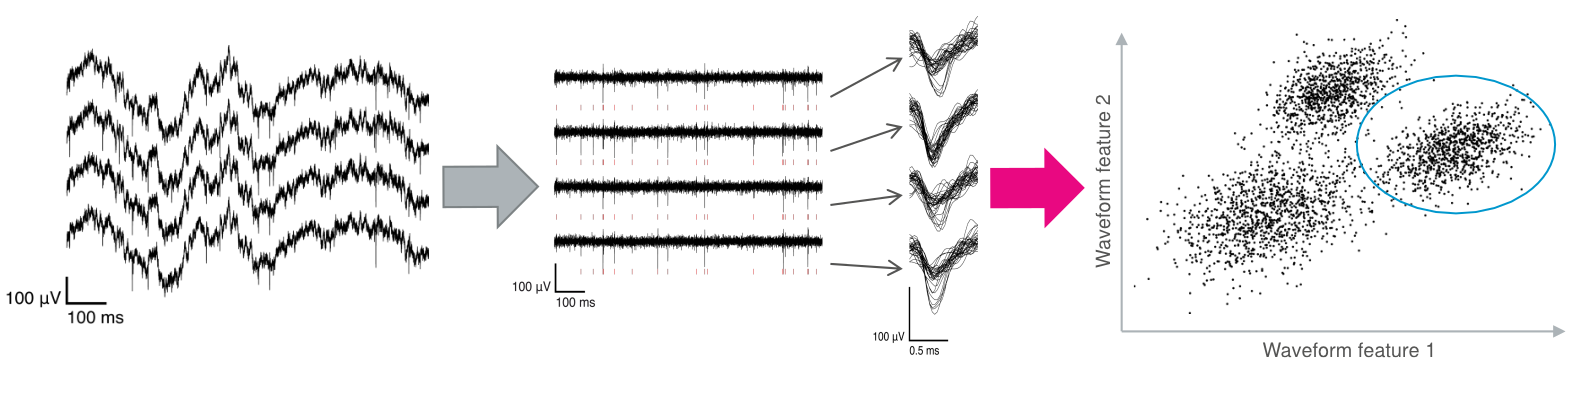

This will later be used for spike sorting (identifying which spike / waveform in the signal was caused by which neuron).

The data used in this notebook was recorded at 30kHz with a tetrode and thus contains the voltage traces of the 4 channels in μV.

_(for more information on the data acquisition, you can have a look at [Ecker et al 2014](https://doi.org/10.1016/j.neuron.2014.02.006), in particular the supplementary material. A similar pipeline is also used in [Ecker et al 2010](https://doi.org/10.1126/science.1179867). Note however that we only use a small portion of the data in this notebook and most of the experiment setup is not relevant here!)_

## Setup
- __Data__: Download the data file ```nds_cl_1.csv``` from ILIAS and save it in a subfolder ```../data/```.
- __Dependencies__: You don't have to use the exact versions of all the dependencies in this notebook, as long as they are new enough. But if you run "Run All" in Jupyter and the boilerplate code breaks, you probably need to upgrade them.


Recommended folder structure:

```
.
├── data/
│   └── nds_cl_1.csv
├── notebooks
│   └── CodingLab1.ipynb
├── matplotlib_style.txt
└── requirements.txt
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import PCA
from __future__ import annotations  # for Python 3.8 and below

# black is a code formatter (see https://github.com/psf/black).
# It will automatically format the code you write in the cells imposing consistent Python style.
%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: 2026-04-22 08:53:07 Romance Summer Time

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 8.18.1

sklearn: 1.7.1

matplotlib: 3.10.3
numpy     : 2.0.1
pandas    : 2.2.3
scipy     : 1.13.1
sklearn   : 1.7.1

Watermark: 2.6.0



In [3]:
# matplotlib style file
# Template for style file: https://matplotlib.org/stable/tutorials/introductory/customizing.html#customizing-with-style-sheets
plt.style.use("../matplotlib_style.txt")

## Load data

In [4]:
fs = 30000.0  # sampling rate of the signal in Hz
dt = 1 / fs
cols = ["Ch1", "Ch2", "Ch3", "Ch4"]
x = pd.read_csv("../data/nds_cl_1.csv", header=0, names=cols)

In [5]:
x.describe()

,Ch1,Ch2,Ch3,Ch4
count,1.920000e+07,1.920000e+07,1.920000e+07,1.920000e+07
mean,3.600331e+00,-8.850918e-01,2.864284e-01,2.210982e+00
std,5.824474e+02,6.014818e+02,6.464363e+02,6.126105e+02
min,-3.607000e+03,-3.739000e+03,-3.871000e+03,-3.750000e+03
25%,-3.460000e+02,-3.610000e+02,-3.950000e+02,-3.640000e+02
50%,1.200000e+01,8.000000e+00,-1.000000e+00,1.000000e+01
75%,3.650000e+02,3.720000e+02,4.010000e+02,3.810000e+02
max,2.873000e+03,3.004000e+03,3.099000e+03,3.017000e+03


## Task 1: Filter Signal

In order to detect action potentials, the first step is to filter out low frequency fluctuations (LFP) and high frequency noise. Determine appropriate filter settings and implement the filtering in the function ```filter_signal()```. A typical choice for this task would be a <mark>butterworth filter</mark>.

Plot a segment of the raw signal and the filtered signal for all four channels with matching y-axis. The segment you choose should contain spikes. When you apply the function also test different filter settings.

*Grading: 3 pts*


In [6]:
def filter_signal(
    x: pd.DataFrame, fs: float, low: float, high: float, order: int = 3
) -> pd.DataFrame:
    """Filter raw signal x.

    Parameters
    ----------

    x: pd.DataFrame, (n_samples, n_channels)
        Each column in x is one recording channel.

    fs: float
        Sampling frequency.

    low, high: float, float
        Passband in Hz for the butterworth filter.

    order: int
        The order of the Butterworth filter. Default is 3, but you should try
        changing this and see how it affects the results.


    Returns
    -------

    y: pd.DataFrame, (n_samples, n_channels)
        The filtered x. The filter delay is compensated in the output y.


    Notes
    ----

    1. Try exploring different filters and filter settings. More info:
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html

    2. The output signal should be phase-shift compensated. More info:
    https://dsp.stackexchange.com/a/19086

    """
    # -----------------------------------------------------------------
    # implement a suitable filter and apply it to the input data (1pt)
    # -----------------------------------------------------------------

    b, a = signal.butter(order, [low, high], "bandpass", output="ba", fs=fs)  # type: ignore
    X_filtered = signal.filtfilt(b, a, x, axis=0)

    X_filtered_df = pd.DataFrame(data=X_filtered, index=x.index, columns=x.columns)

    return X_filtered_df

In [71]:
xf = filter_signal(x, fs, low=500, high=4000, order=2)

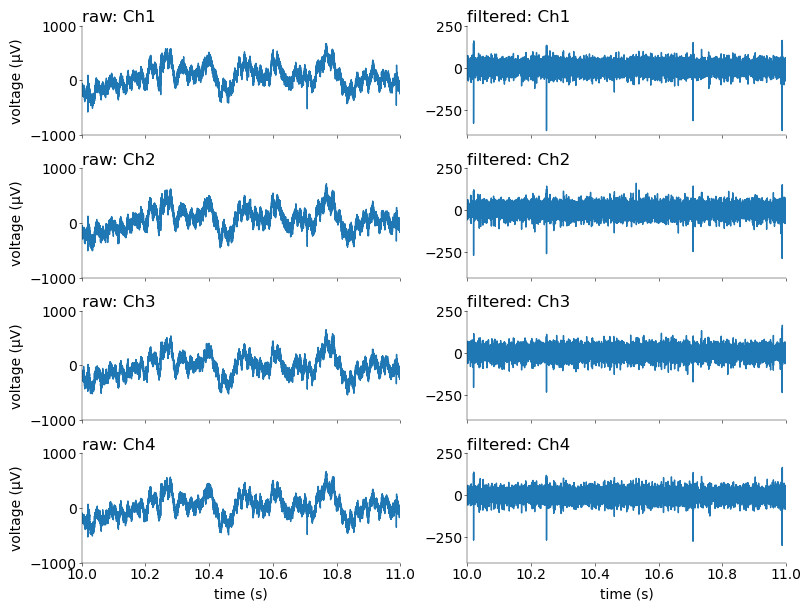

In [72]:
mosaic = [
    ["raw: Ch1", "filtered: Ch1"],
    ["raw: Ch2", "filtered: Ch2"],
    ["raw: Ch3", "filtered: Ch3"],
    ["raw: Ch4", "filtered: Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------------
# Plot raw and filtered signals for all 4 channels and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------

t_start, t_end = 10, 11
i_start, i_end = int(t_start * fs), int(t_end * fs)

t = np.arange(t_start, t_end, dt)

for channel, (raw, filtered) in enumerate(mosaic):

    ax[raw].plot(t, x.iloc[i_start:i_end, channel])
    ax[filtered].plot(t, xf.iloc[i_start:i_end, channel])

    ax[raw].set_xlim((t_start, t_end))
    ax[raw].set_ylim((-1000, 1000))

    ax[filtered].set_xlim((t_start, t_end))
    ax[filtered].set_ylim((-400, 250))

    # Add labels and title
    ax[raw].set_ylabel("voltage (μV)")
    ax[raw].set_title(raw, loc="left")
    ax[filtered].set_title(filtered, loc="left")
    if channel != 3:
        ax[raw].set_xticklabels([])
        ax[filtered].set_xticklabels([])
    else:
        ax[raw].set_xlabel("time (s)")
        ax[filtered].set_xlabel("time (s)")

### Questions
1) Explain your implementation: Which filter and parameters did you choose and why?

In the lecture we discussed that APs have the most power in 500-100 Hz range. So I extended this a bit into the higher frequencies to be sure, and the result looks appealing. APs are retained, but the slow oscillations are still filtered out.

1) Which parameters of the function can be adjusted, which are determined by the experiment setup? What is the effect of the adjustable parameters?

determined: fs; adjustable: low & high frequency cutoff, order of the filter (steepness of cutoff, no obvious visual effects, but it would be clearer in frequency domain), the lower bound of the frequency cutoff determines the slow frequencies that we filter out, high cutoff alike.

2) How does the filtered signal look compared to the original? Why is this helpful as preprocessing in our spike detection pipeline?

filtered, now we can set clear cutoffs for the action potentials.

## Task 2: Detect action potentials

Action potentials are usually detected by finding large-amplitude deflections in the continuous signal. A good choice of threshold for detecting spikes is important. If it is too low, you will detect too many low amplitude events (noise); if it is too high, you run the risk of missing good spikes. Implement an automatic procedure to obtain a reasonable threshold and detect the times when spikes occurred in the function ```detect_spikes()```.

Plot a segment of the filtered signal for all four channels with matching y-axis and indicate the time points where you detected spikes, also **plot the threshold**.

*Grading: 4 pts*

In [73]:
def detect_spikes(
    x: pd.DataFrame, fs: float, N: int = 5, lockout: float = 1.0
) -> tuple[np.ndarray, np.ndarray, np.float64]:
    """Detect spikes in the signal x and compute a threshold.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal from Task 1.

    fs: float
        the sampling rate (in Hz).

    N: int
        An arbitrary number with which you multiply with the standard deviation
        to set a threshold that controls your false positive rate. Default is 5
        but you should try changing it and see how it affects the results.

    lockout: float
        a window of 'refractory period', within which there's only one spike.
        Default is 1ms but you should also try changing it.


    Returns
    -------

    s: np.array, (n_spikes, )
        Spike location / index in the signal x.

    t: np.array, (n_spikes, )
        Spike time in ms. By convention the time of the zeroth sample is 0 ms.

    thrd: float
        Threshold = -N * sigma.


    Tips
    ----

    You can use scipy functions like find_peaks for the detection.
    Note: There are four channels in signal x.

    """
    # --------------------------------------------------------------
    # compute the robust s.d. and calculate the threshold (0.5 pts)
    # --------------------------------------------------------------

    array = x.to_numpy().flatten()
    median = np.median(array)
    MAD = np.median(
        np.abs(array - median)
    )  # Median absolute deviation (here: from median)
    sigma_estimation = MAD / 0.6745

    thrd = sigma_estimation * N

    # --------------------------
    # find all spikes (1.5 pts)
    # --------------------------

    merged_channel = np.min(
        x.to_numpy(), axis=1
    )  # we check if the threshold is reached in at least one of the channels

    peaks, props = signal.find_peaks(
        -merged_channel, height=thrd, distance=lockout * fs / 1000
    )

    t_points = (peaks / fs) * 1000

    return peaks, t_points, -thrd

In [74]:
s, t_spikes, thrd = detect_spikes(xf, fs=fs, N=2.5, lockout=1)

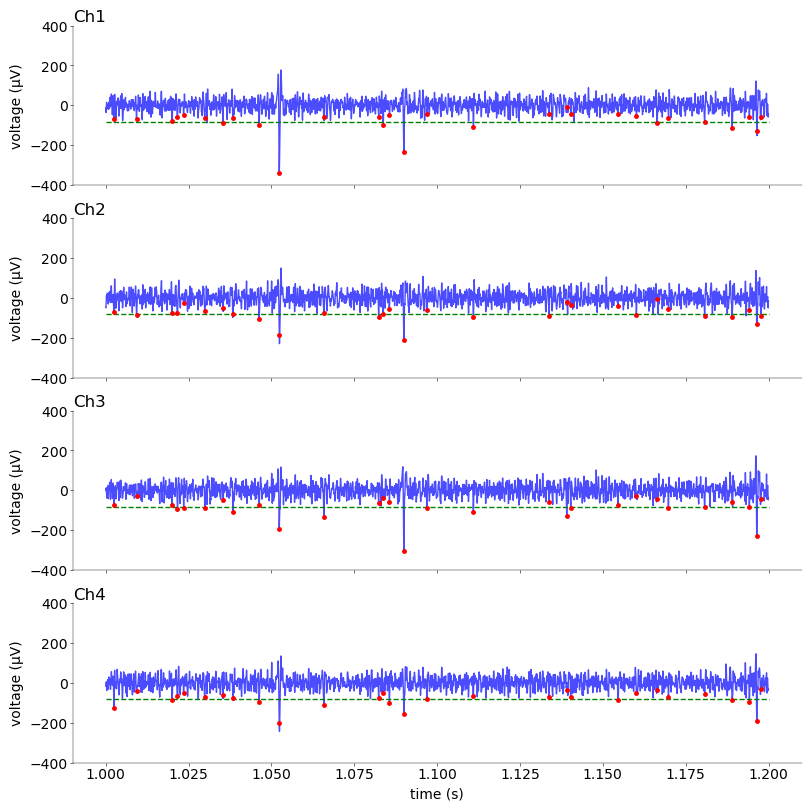

In [75]:
mosaic = [
    ["Ch1"],
    ["Ch2"],
    ["Ch3"],
    ["Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# ------------------------------------------------------------------------------
# plot signal, threshold and detected spikes
# ------------------------------------------------------------------------------

t_start, t_end = 1, 1.2
i_start, i_end = int(t_start * fs), int(t_end * fs)

# Continuous time vector for the x-axis (in seconds)
t = np.arange(t_start, t_end, dt)

for i, col in enumerate(cols):

    # 1. Plot the continuous filtered signal
    ax[col].plot(t, xf.iloc[i_start:i_end, i], color="blue", alpha=0.7)

    # 2. Plot the threshold line
    ax[col].hlines(
        y=thrd, xmin=t_start, xmax=t_end, colors="green", linestyles="dashed"
    )

    # 3. Filter the spikes to only include those within the current plotting window
    valid_spikes_mask = (s >= i_start) & (s < i_end)
    spikes_in_window = s[valid_spikes_mask]

    # 4. Calculate exact coordinates for the scatter plot
    spike_times_sec = spikes_in_window / fs
    spike_voltages = xf.iloc[spikes_in_window, i]

    # 5. Overlay the spikes as distinct red dots
    ax[col].plot(
        spike_times_sec,
        spike_voltages,
        marker="o",
        color="red",
        linestyle="none",
        markersize=2.5,
    )

    # Formatting
    ax[col].set_ylim((-400, 400))
    ax[col].set_ylabel("voltage (μV)")
    ax[col].set_title(col, loc="left")

    if col != "Ch4":
        ax[col].set_xticklabels([])
    else:
        ax[col].set_xlabel("time (s)")

plt.show()

### Questions

1) Are the detected time points well aligned with prominent extrema in the signal? Also compare your detections across channels.

yes, they are quite consistent. peaks that are not sig in one channel but the other are shown.

2) Take one feature of the spikes and explain how that can help us identifying the source neuron of a spike (only based on visual examination of the plot).

the first spike visible in this plot has the strongest amplitude in channel 1. therefore we can assume it is closest there, and farther away from the channels in which its amplitude is lower

## Task 3: Extract waveforms
For later spike sorting we need the waveforms of all detected spikes. Extract the waveforms segments (1 ms) on all four channels for each spike time (as a result each spike is represented by a 4x30 element matrix). Implement this procedure in the function ```extract_waveforms()```.

Plot (a) the first 100 spikes you detected and (b) the 100 largest spikes you detected.
Are there a lot of very small spikes (likely noise) among your detected spikes? If so your threshold may be too low. Can you see obvious artifacts, not looking like spikes at all?

*Grading: 3 pts*

In [76]:
def extract_waveforms(x: np.ndarray, s: np.ndarray) -> np.ndarray:
    """Extract spike waveforms at times s (given in samples)
    from the filtered signal `xf` using a fixed window around the
    times of the spikes.

    Parameters
    ----------

    x: np.array (n_samples, n_channels)
        The filtered signal.

    s: np.array, (n_spikes, )
        Spike time in samples.


    Return
    ------

    w: np.array, (n_spikes, length_window, n_channels)
        Waveforms. (You don't have to get the exact same
        shape as we noted here. It's just the shape of w
        that can be easily retrieved via broadcasting.)


    Notes
    -----

    More on Numpy Broadcasting
    https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

    """
    # -------------------------------
    # extract spike waveforms (1 pt)
    # -------------------------------

    # Define a fixed window around the spike (adjust these numbers as needed)
    around = int(0.5 * fs / 1000)  # Samples to extract before the spike

    # Create the base window array: shape (length_window, )
    window = np.arange(-around, around)

    # Use broadcasting to create an index matrix of shape (n_spikes, length_window)
    # s[:, None] converts s to shape (n_spikes, 1)
    # Adding `window` broadcasts the sum across columns, creating all necessary indices.
    # both s and window are broadcasted to shape (n_spikes, length_window) in the resulting idx.
    idx = s[:, None] + window

    # Use "advanced indexing" to fetch the waveforms.
    # Because x is (n_samples, n_channels) and idx is (n_spikes, length_window),
    # x[idx] elegantly returns an array of shape (n_spikes, length_window, n_channels).
    # we basically tell it to iterate through idx, (first rows, then columns), and take whatever index is there call it i. then we take the [i, :], so the ith row and place it in result[row, column, :]. This is done for all rows and columns in idx.
    w = x[idx, :]

    return w

In [77]:
w = extract_waveforms(xf.to_numpy(), s)

Plot first 100 spike waveforms

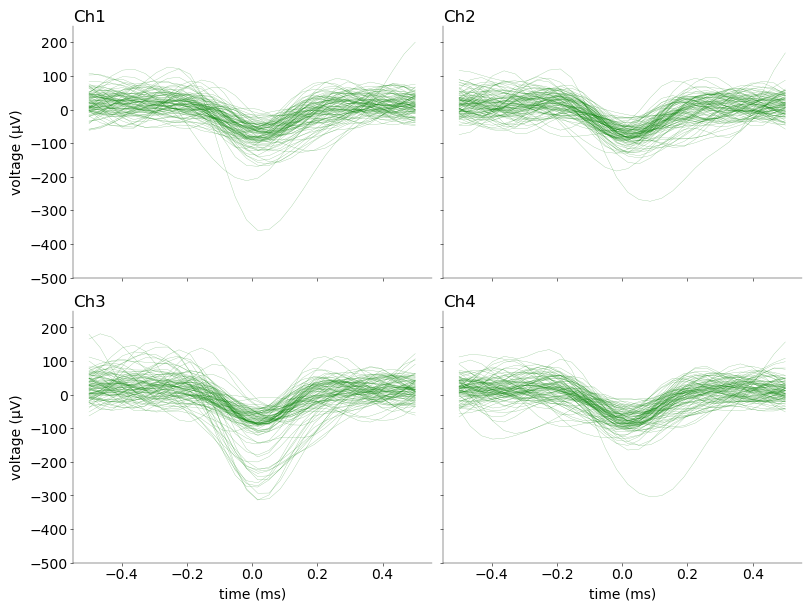

In [79]:
# ---------------------------------------------------------------------
# plot first and largest 100 spikes and answer the questions (1+1 pts)
# ---------------------------------------------------------------------

# first 100 spikes

mosaic = [
    ["Ch1", "Ch2"],
    ["Ch3", "Ch4"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

t = np.linspace(-0.5, 0.5, w.shape[1])

for i, col in enumerate(cols):

    # 2. Pass 't' as the first argument so the x-axis scales correctly
    ax[col].plot(t, w[:100, :, i].T, color="green", alpha=0.5, linewidth=0.2)

    # labeling etc
    ax[col].set_ylim((-500, 250))
    # ax[col].set_xlim((-0.33, 0.66))  # Now this will frame the central spike perfectly!
    ax[col].set_title(col, loc="left")

    if col == "Ch3" or col == "Ch4":
        ax[col].set_xlabel("time (ms)")
    else:
        ax[col].set_xticklabels([])

    if col == "Ch1" or col == "Ch3":
        ax[col].set_ylabel("voltage (μV)")
    else:
        ax[col].set_yticklabels([])

Plot largest 100 spike waveforms

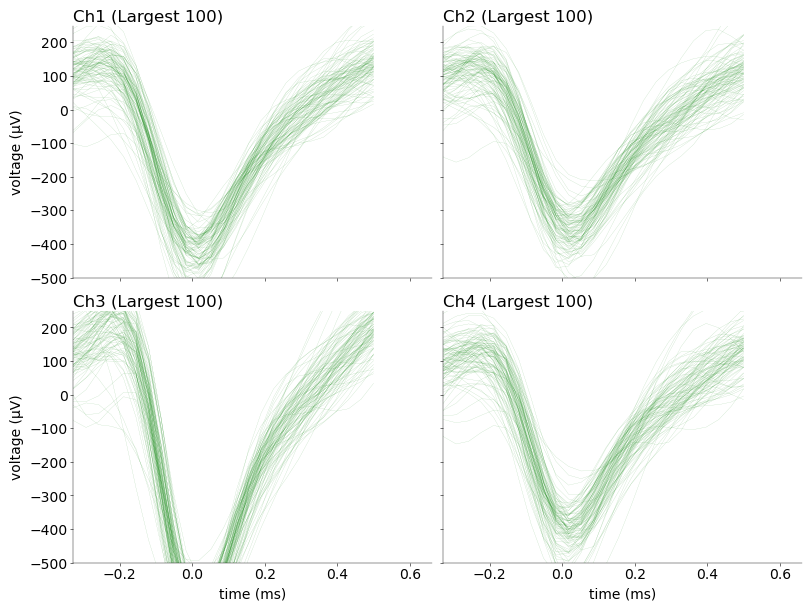

In [80]:
# ---------------------------------------------------------------------
# plot largest 100 spikes
# ---------------------------------------------------------------------

# 1. Calculate peak-to-peak (ptp) amplitude for every spike on every channel
# np.ptp along axis 1 (the time window) gives an array of shape (n_spikes, n_channels)
amplitudes = np.ptp(w, axis=1)

# 2. Find the absolute max amplitude across all 4 channels for each individual spike
# This gives us a 1D array of shape (n_spikes,)
max_amplitudes = np.max(amplitudes, axis=1)

# 3. Get the indices of the top 100 largest amplitudes
# np.argsort sorts from smallest to largest, so [-100:] grabs the last (biggest) 100
largest_100_idx = np.argsort(max_amplitudes)[-100:]

# 4. Create the plot using those indices
fig2, ax2 = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 6), layout="constrained", dpi=100
)

# Recreate the time vector just in case (spanning -0.5ms to 0.5ms)
t = np.linspace(-0.5, 0.5, w.shape[1])

for i, col in enumerate(cols):

    # Plot using our new indices. Transpose (.T) is still required!
    ax2[col].plot(
        t, w[largest_100_idx, :, i].T, color="green", alpha=0.5, linewidth=0.1
    )

    # labeling etc
    ax2[col].set_ylim((-500, 250))
    ax2[col].set_xlim((-0.33, 0.66))
    ax2[col].set_title(f"{col} (Largest 100)", loc="left")

    if col == "Ch3" or col == "Ch4":
        ax2[col].set_xlabel("time (ms)")
    else:
        ax2[col].set_xticklabels([])

    if col == "Ch1" or col == "Ch3":
        ax2[col].set_ylabel("voltage (μV)")
    else:
        ax2[col].set_yticklabels([])

plt.show()

### Questions

1) Describe the shape of the spikes.

they look pretty good, all are at least notably deflected to the negative range

1) Do the waveforms tend to be similar? If spikes have a similar waveform, what could that mean - and what does it mean if the waveforms look different?

the do look similar, which could mean that they are all from the same (nearest?) neuron

## Task 4: Extract features using PCA
Compute the first three PCA features on each channel separately in ```extract_features()```. You can use a available PCA implementation or implement it yourself. After that, each spike is represented by a 12 element vector. Compute the fraction of variance captured by these three PCs. Also return the obtained parameters of the PCA

For one channel, plot the mean and the first three principal axes as calculated by the PCA in the feature space. Interprete them in light of the plots in the previous tasks.

For all pairwise combinations of channels, plot the resulting features of the 1st PCs as scatter plots against each other. Do you see clusters visually?

*Grading: 6 pts*

## PCA
### Questions (1 pt)
1) If we input the data from each channel separately to a PCA, what are the feature dimension of the input?

The input will be (n_spikes, length_window), and we perform the PCA such that the spike-points live in samplespace. Each spike will be composed of 30 datapoints.

2) Therefore, what do the Principal Axes the PCA computes represent?

The main directions in which the spikes deviate from each other, where the inter-spike variability is highest. The first waveform will give us the characteristic largest deviation from the mean/average spike (which is subtracted during the PCA calculations). The PCAs therefore often reflect systematic variations, PC1 being amplitude for example.

3) Does it make sense to apply preprocessing steps, such as normalization? Have a look at the [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). What is applied by default?

The amplitue is among the most informative feature and would get lost during normalization. Therefore, we do not want to normalize. This can be done because all dimensions are of the same unit and therefore do not differ by multiple orders of magnitude.

In [ ]:
def extract_features(w: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract features for spike sorting from the waveforms w.

    Do PCA on the waveforms of each channel separately,
    then concatenate the first three principal components
    of each channels into one numpy array (`b`).


    Parameter
    ---------

    w: np.ndarray, (n_spikes, length_window, n_channels)
        Waveforms from Task 3.


    Return
    ------

    b: np.ndarray, (n_spikes, n_feature)
        the transformed data
    means: np.ndarray, (n_channels, length_window)
        means per channel
    principal_components: np.ndarray, (n_channels, 3, length_window)
        the 'principal axes' obtained by the pca
    """

    # Extract shapes for dynamic sizing
    n_spikes, length_window, n_channels = w.shape

    # Initialize arrays and lists to store our results
    b_features = []
    means = np.zeros((n_channels, length_window))
    principal_components = np.zeros((n_channels, 3, length_window))

    # ----------------------------------------------
    # obtain first 3 principle components (1.5 pts)
    # ----------------------------------------------

    for i in range(n_channels):
        # Isolate the data for a single channel: shape (n_spikes, length_window)
        channel_data = w[:, :, i]

        # Initialize PCA to keep only the top 3 components
        pca = PCA(n_components=3)

        # fit_transform automatically subtracts the mean and projects
        # the data onto the 3 principal axes
        transformed_data = pca.fit_transform(channel_data)

        # Store the transformed features, mean, and components
        b_features.append(transformed_data)
        means[i] = pca.mean_
        principal_components[i] = pca.components_

        # -----------------------------------------------------------------------------------------------------
        # Print the fraction of variance explained by the three components combined for each channel (0.5 pts)
        # -----------------------------------------------------------------------------------------------------
        # explained_variance_ratio_ gives an array of length 3 (one for each PC).
        # We sum them to get the total variance explained by our 3D projection.
        total_variance_explained = np.sum(pca.explained_variance_ratio_)

        # Using :.2% formats the decimal as a nice percentage (e.g., 0.854 -> 85.40%)
        print(
            f"Channel {i+1} (Ch{i+1}): The first 3 PCs explain {total_variance_explained:.2%} of the variance."
        )

    # Concatenate the feature lists horizontally (axis=1)
    # This transforms 4 arrays of shape (n_spikes, 3) into one array of shape (n_spikes, 12)
    b = np.concatenate(b_features, axis=1)

    return b, means, principal_components

Channel 1 (Ch1): The first 3 PCs explain 76.21% of the variance.
Channel 2 (Ch2): The first 3 PCs explain 70.64% of the variance.
Channel 3 (Ch3): The first 3 PCs explain 75.28% of the variance.
Channel 4 (Ch4): The first 3 PCs explain 72.19% of the variance.


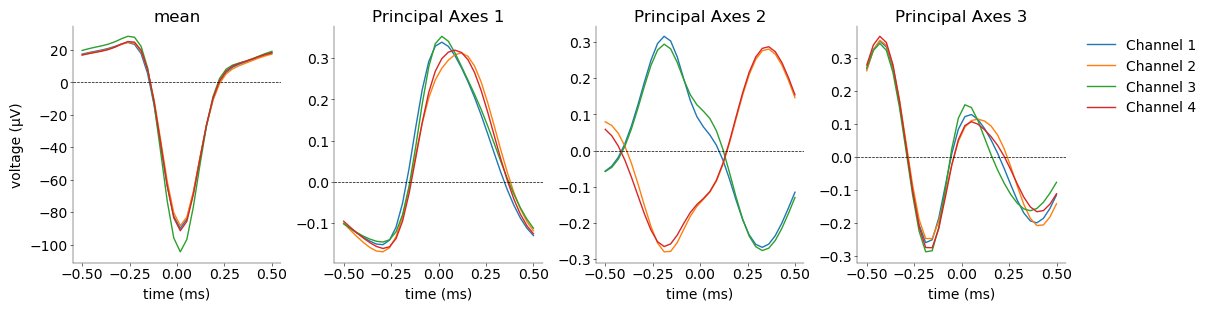

In [84]:
# ------------------------------------------------------------------------------------------------------------------
# Plot the mean of each channel and the three principal axes obtained by the PCA and answer the questions (1+1 pts)
# ------------------------------------------------------------------------------------------------------------------

b, means, principal_components = extract_features(w)

# Recreate the time vector to match the window length
t = np.linspace(-0.5, 0.5, means.shape[1])

mosaic = [
    ["mean", "Principal Axes 1", "Principal Axes 2", "Principal Axes 3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(12, 3), layout="constrained", dpi=100
)

for channel in range(4):
    # Plot the mean for the current channel
    ax["mean"].plot(t, means[channel])

    # Plot the 1st, 2nd, and 3rd principal axes (components)
    # Remember: Python is 0-indexed, so 0 is PC1, 1 is PC2, etc.
    ax["Principal Axes 1"].plot(t, principal_components[channel, 0])
    ax["Principal Axes 2"].plot(t, principal_components[channel, 1])
    ax["Principal Axes 3"].plot(t, principal_components[channel, 2])

# Add labeling and formatting
for i, mo in enumerate(np.ravel(mosaic)):
    ax[mo].set_xlabel("time (ms)")
    ax[mo].set_title(mo)

    # Optional: Draw a horizontal line at y=0 to help visualize the waveforms
    ax[mo].axhline(0, color="black", linewidth=0.5, linestyle="--")

ax["mean"].set_ylabel("voltage (μV)")  # Only the mean is in microvolts!

ax[mosaic[0][-1]].legend(
    ["Channel " + str(i + 1) for i in range(4)],
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)
plt.show()

### Questions

1) Compare the plot to the plots of the other tasks. What do you observe?

The mean is just the average trace, the principle components are unit vectors in directions of the most important deviations. The first PC here resembles a (intverted) AP and therefore can just be understood as a scaling vector, which has the biggest impact on the spike amplitude. further PCs reflect other deviations, such as temporal offsets, widths, and so on.

2) What does the mean look like? Does this match your expectations?

yes, it reflects the typical shape of an externally recorded AP close to the soma, with a strong strong negative bump, and a light overshoot.

3) Explain what it means if a spike has a high value in the first dimension. What is the effect of the other dimensions?

As described above, this means that amplitude is one of the most variable features of the spike. The other dimensions then look for eg width, shifts in wave shape if it was closer to a dendrite, or other features where the variability is large enough.

Text(0.5, 0.98, 'Pairwise 1st PCs')

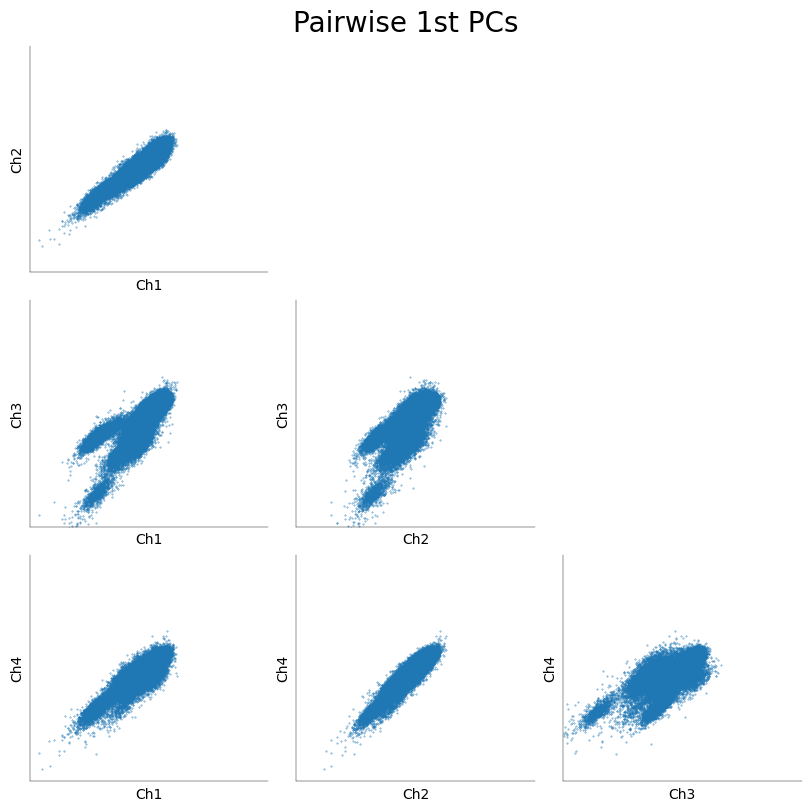

In [94]:
# ----------------------------------------------------------------------------------------------------------
# Create a scatterplot of the projections of the spikes for all pairwise combinations of the 1st PCs (1 pt)
# ----------------------------------------------------------------------------------------------------------

mosaic = [
    ["Ch2 vs Ch1", ".", "."],
    ["Ch3 vs Ch1", "Ch3 vs Ch2", "."],
    ["Ch4 vs Ch1", "Ch4 vs Ch2", "Ch4 vs Ch3"],
]
fig, ax = plt.subplot_mosaic(
    mosaic=mosaic, figsize=(8, 8), layout="constrained", dpi=100
)

# index of the 1st PC in `b`
i = {"Ch1": 0, "Ch2": 3, "Ch3": 6, "Ch4": 9}

for mo in np.ravel(mosaic):
    if mo == ".":
        continue
    y, x = mo.split(" vs ")

    ax[mo].scatter(b[:, i[x]], b[:, i[y]], s=0.5, alpha=0.8)

    ax[mo].set_xlabel(x)
    ax[mo].set_ylabel(y)
    ax[mo].set_xlim((-1500, 1500))
    ax[mo].set_ylim((-1500, 1500))
    ax[mo].set_xticks([])
    ax[mo].set_yticks([])

fig.suptitle("Pairwise 1st PCs", fontsize=20)

In [86]:
# save data for the next Coding Lab

np.save("../data/nds_cl_1_features", b)
np.save("../data/nds_cl_1_spiketimes_s", s)
np.save("../data/nds_cl_1_spiketimes_t", t)
np.save("../data/nds_cl_1_waveforms", w)